In [1]:
from data.dataset import DOGVideoREIDDataset
from configs.config import Config
from data.transforms import ViTVideoTransform
from torch.utils.data import DataLoader
from pytorch_metric_learning.samplers import MPerClassSampler
cfg = Config()

In [2]:

train_dataset = DOGVideoREIDDataset(
    root_dir=cfg.data_root,
    split_file=cfg.split_file,
    split="train",
    world=cfg.world,
    clip_len=cfg.clip_len,
    transform=ViTVideoTransform()
)


query_dataset = DOGVideoREIDDataset(
    root_dir=cfg.data_root,
    split_file=cfg.split_file,
    split="query",
    world=cfg.world,
    clip_len=cfg.clip_len,
    transform=ViTVideoTransform()
)

sampler = MPerClassSampler(
    labels=train_dataset.labels,  
    m=2                     
)

In [3]:
print("Dataset size:", len(train_dataset))

clip, label, dog_id, video_id = train_dataset[64]

print("Clip shape:", clip.shape)
print("Label:", label)
print("Dog ID:", dog_id)
print("Video ID:", video_id)

Dataset size: 3756
Clip shape: torch.Size([16, 3, 224, 224])
Label: 10
Dog ID: 0306db0b-0e06-4343-ab9d-ea3ec4777d9a
Video ID: 5d56638a-aeb2-47b4-ba1f-57fa588df005


In [4]:
print("Dataset size:", len(query_dataset))

clip, label, dog_id, video_id = query_dataset[43]

print("Clip shape:", clip.shape)
print("Label:", label)
print("Dog ID:", dog_id)
print("Video ID:", video_id)

Dataset size: 1594
Clip shape: torch.Size([16, 3, 224, 224])
Label: 16
Dog ID: 0452d596-3bf1-41fa-a7df-60b5be8db69f
Video ID: 496bccbe-ed3d-48fb-9319-bf1cca92a793


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,   # must = num_ids * num_instances
    sampler=sampler,
    num_workers=4,
    drop_last=True
)

query_loader = DataLoader(
    query_dataset,
    batch_size=cfg.batch_size,   # must = num_ids * num_instances
    sampler=sampler,
    num_workers=4,
    drop_last=True
)

In [6]:
len(train_loader)

12462

In [7]:
import matplotlib.pyplot as plt
import torch

batch = next(iter(train_loader))
clips, labels, dog_ids, video_ids = batch
print(dog_ids)


('23aa587c-5810-41a0-ba7d-61a9fe4fd7b1', '23aa587c-5810-41a0-ba7d-61a9fe4fd7b1', 'a40762ac-b6ce-4639-825a-a16e25e85c8f', 'a40762ac-b6ce-4639-825a-a16e25e85c8f', '482803e2-cc0a-4b67-9758-405b85faf7d3', '482803e2-cc0a-4b67-9758-405b85faf7d3', 'bd428c27-7f61-443c-a917-3969290ae317', 'bd428c27-7f61-443c-a917-3969290ae317')


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001F3682DA7A0>
Traceback (most recent call last):
  File "c:\Users\marko\miniconda3\envs\dog_reid\lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "c:\Users\marko\miniconda3\envs\dog_reid\lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


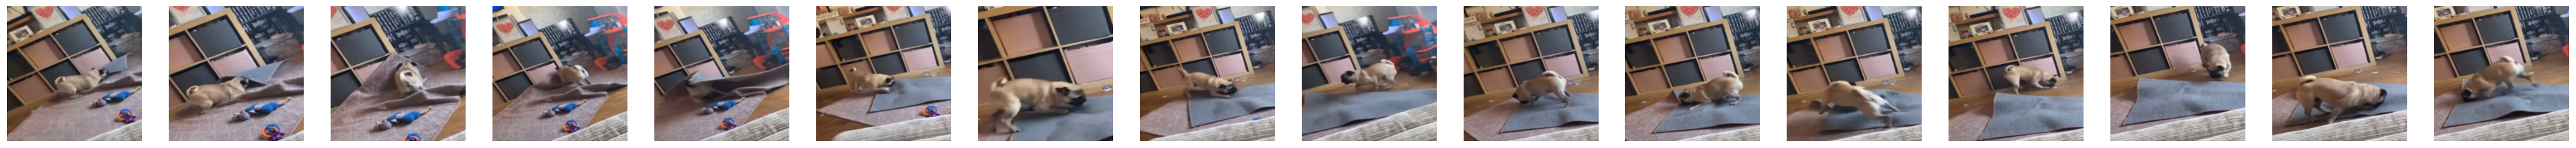

In [18]:
clip = clips[5]   # (T, C, H, W)

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

T = clip.shape[0]

fig, axes = plt.subplots(1, T, figsize=(3*T,3))

# ensure axes is iterable
if T == 1:
    axes = [axes]
    print("here")

for i in range(T):
    frame = clip[i]

    frame = frame * std + mean
    frame = frame.permute(1,2,0)

    axes[i].imshow(frame.numpy())
    axes[i].axis("off")

plt.show()

In [9]:
import torch

def compute_similarity_matrix(self, qf, gf):

    qf = torch.nn.functional.normalize(qf, dim=1)
    gf = torch.nn.functional.normalize(gf, dim=1)

    sim_mat = qf @ gf.T

    return sim_mat


def compute_metrics(self, similarity_mat, query_labels, gallery_labels):

    query_labels = torch.tensor(query_labels)
    gallery_labels = torch.tensor(gallery_labels)

    num_queries = len(query_labels)
    num_gallery = len(gallery_labels)

    cmc_curve = torch.zeros(num_gallery)

    ap_list = []

    print(similarity_mat.shape)
    print(len(query_labels), len(gallery_labels))

    for query_label, similarity_row in zip(query_labels, similarity_mat):

        sorted_indices = torch.argsort(similarity_row, descending=True)

        matches = (gallery_labels[sorted_indices] == query_label).float()

        if matches.sum() == 0:
            continue

        rank = matches.nonzero(as_tuple=False)[0].item()

        cmc_curve[rank:] += 1

        cum_matches = matches.cumsum(0)

        precision_at_k = cum_matches / torch.arange(
            1, num_gallery + 1, dtype=torch.float32
        )

        ap = (precision_at_k * matches).sum() / matches.sum()

        ap_list.append(ap)

    cmc_curve = cmc_curve / num_queries

    mAP = torch.stack(ap_list).mean().item()

    return cmc_curve, mAP

In [10]:
import torch

# 3 queries, 5 gallery items
query_labels = [0, 1, 2]
gallery_labels = [0, 1, 2, 3, 4]

# fake similarity (force correct ranking)
similarity_mat = torch.tensor([
    [0, 0.1, 0.2, 0.4, 0.0],  # query 0 → best match index 0
    [0.1, 0.9, 0.2, 0.0, 0.0],  # query 1 → index 1
    [0.1, 0.9, 0.4, 0.0, 0.0],  # query 2 → index 2
])

cmc, mAP = compute_metrics(None, similarity_mat, query_labels, gallery_labels)

print("CMC:", cmc)
print("mAP:", mAP)

torch.Size([3, 5])
3 5
CMC: tensor([0.3333, 0.6667, 0.6667, 1.0000, 1.0000])
mAP: 0.5833333134651184


In [11]:
cfg = Config()
print(cfg.device)

cuda


In [12]:
import torch

from configs.config import Config
from data.dataloader import build_dataloaders
from models.model_factory import build_model
from engine.trainer import Trainer


def main():

    # Load configuration
    cfg = Config()

    print(f"Evaluating with model: {cfg.model}")

    # Build dataloaders
    # train_loader is unused but returned by the function
    train_loader, query_loader, gallery_loader = build_dataloaders(cfg)

    # Build pretrained model
    model = build_model(cfg)

    # Optimizer not needed for evaluation, but Trainer expects it
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    # Create trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        query_loader=query_loader,
        gallery_loader=gallery_loader,
        optimizer=optimizer,
        device=cfg.device,
        cfg=cfg
    )

    # Run evaluation
    rank1, rank5, mAP = trainer.evaluate()

    print("\nEvaluation Results")
    print(f"Rank-1: {rank1:.4f}")
    print(f"Rank-5: {rank5:.4f}")
    print(f"mAP: {mAP:.4f}")


if __name__ == "__main__":
    main()

Evaluating with model: vit


Querying:   0%|          | 0/100 [00:23<?, ?it/s]


KeyboardInterrupt: 

In [19]:
import torch
import numpy as np

def compute_metrics(similarity_mat, query_labels, gallery_labels, topk=[1, 5]):
    """
    Stand-alone version of the metrics function.
    """
    query_labels = torch.tensor(query_labels)
    gallery_labels = torch.tensor(gallery_labels)
    num_queries = len(query_labels)
    num_gallery = len(gallery_labels)

    cmc_curve = torch.zeros(num_gallery)
    ap_list = []

    for i in range(num_queries):
        sim_row = similarity_mat[i]
        
        # Sort indices by highest similarity
        sorted_idx = torch.argsort(sim_row, descending=True)
        
        # Get labels of sorted gallery items
        matched_labels = gallery_labels[sorted_idx]
        
        # Binary mask: 1 where it matches the query dog_id
        matches = (matched_labels == query_labels[i]).float()

        # --- OPTIONAL: SELF-MATCH REMOVAL ---
        # If your 100% was due to the exact same video being in Q and G, 
        # uncomment the next line to ignore the top match.
        # matches = matches[1:] 
        # ------------------------------------

        if matches.sum() == 0:
            continue

        # Rank-N (CMC)
        # Find index of the first '1'
        rank = (matches == 1).nonzero(as_tuple=False)[0].item()
        cmc_curve[rank:] += 1

        # Average Precision (AP)
        cum_matches = matches.cumsum(0)
        precision = cum_matches / torch.arange(1, len(matches) + 1)
        ap = (precision * matches).sum() / matches.sum()
        ap_list.append(ap)

    # Final calculations
    cmc = cmc_curve / num_queries
    mAP = torch.tensor(ap_list).mean().item()
    
    return cmc, mAP

def main(feature_path):
    print(f"Loading features from {feature_path}...")
    data = torch.load(feature_path)
    
    q_feats = data['query_feats']
    q_ids = data['query_ids']
    g_feats = data['gallery_feats']
    g_ids = data['gallery_ids']

    print(f"Query: {q_feats.shape} | Gallery: {g_feats.shape}")

    # Calculate similarity (Cosine similarity if features are normalized)
    # Using matrix multiplication: (Q x D) @ (D x G) -> (Q x G)
    print("Calculating similarity matrix...")
    sim_mat = q_feats @ g_feats.T

    # Compute Metrics
    cmc, mAP = compute_metrics(sim_mat, q_ids, g_ids)

    print("\n--- Evaluation Results ---")
    print(f"mAP:    {mAP:.4f}")
    print(f"Rank-1: {cmc[0]:.4f}")
    print(f"Rank-5: {cmc[4]:.4f}")
    print(f"Rank-10:{cmc[9]:.4f}")

    # Debugging check: Is the first match distance very suspicious?
    top_sims = sim_mat.max(dim=1)[0]
    print(f"\nAvg Top Similarity: {top_sims.mean():.4f}")
    if top_sims.mean() > 0.999:
        print("ALERT: Extremely high similarity detected. Check for duplicate videos in Q and G.")

if __name__ == "__main__":
    # Point this to your saved .pt file
    FEATURE_FILE = "output/eval_features_debug.pt"
    main(FEATURE_FILE)

Loading features from output/eval_features_debug.pt...


FileNotFoundError: [Errno 2] No such file or directory: 'output/eval_features_debug.pt'